In [37]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import label


In [31]:
img = nib.load("./processed/R3001/mri/T1.mgz")
data = img.get_fdata()
np.percentile(data, 70)

17.0

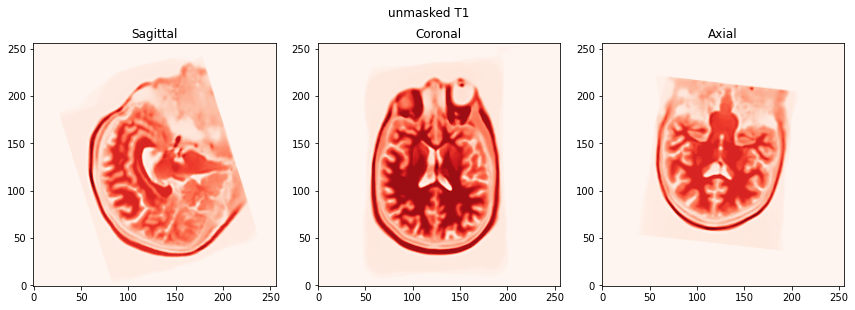

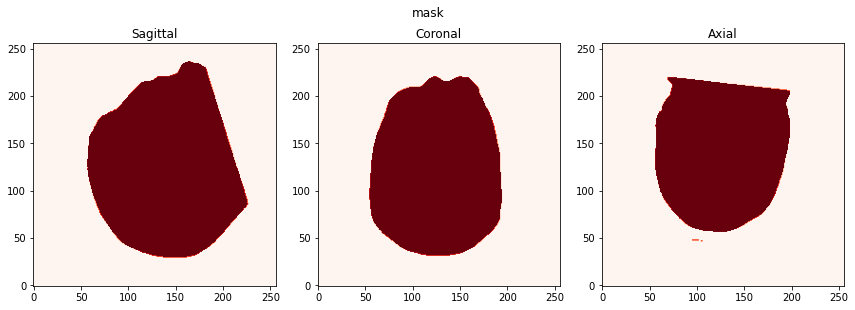

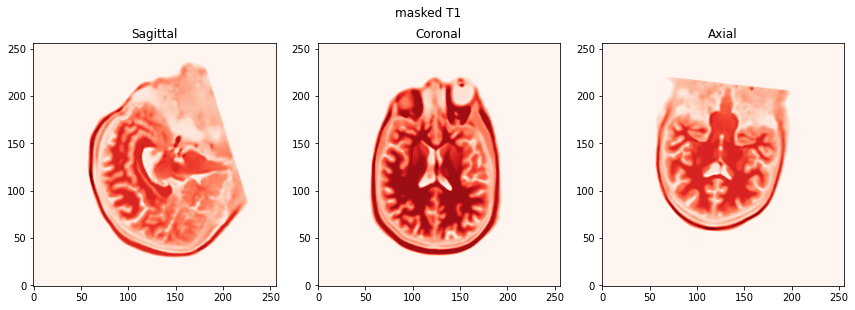

In [83]:
img = nib.load("./processed/R2884/mri/T1.mgz")
data = img.get_fdata()

data0 = data - np.percentile(data, 85)
mask = data0 < 0

lab, _ = label(mask)
sizes = np.bincount(lab.ravel())
sizes[0] = 0
mask = ~(lab == sizes.argmax())


# Choose middle slices
x = mask.shape[0] // 2
y = mask.shape[1] // 2
z = mask.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(data[x, :, :].T, cmap="Reds", origin="lower")
axes[0].set_title("Sagittal")

axes[1].imshow(data[:, y, :].T, cmap="Reds", origin="lower")
axes[1].set_title("Coronal")

axes[2].imshow(data[:, :, z].T, cmap="Reds", origin="lower")
axes[2].set_title("Axial")

plt.tight_layout()
plt.suptitle("unmasked T1", y=1.05)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(mask[x, :, :].T, cmap="Reds", origin="lower")
axes[0].set_title("Sagittal")

axes[1].imshow(mask[:, y, :].T, cmap="Reds", origin="lower")
axes[1].set_title("Coronal")

axes[2].imshow(mask[:, :, z].T, cmap="Reds", origin="lower")
axes[2].set_title("Axial")

plt.tight_layout()
plt.suptitle("mask", y=1.05)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))


axes[0].imshow(data[x, :, :].T * mask[x, :, :].T, cmap="Reds", origin="lower")
axes[0].set_title("Sagittal")

axes[1].imshow(data[:, y, :].T * mask[:, y, :].T, cmap="Reds", origin="lower")
axes[1].set_title("Coronal")

axes[2].imshow(data[:, :, z].T * mask[:, :, z].T, cmap="Reds", origin="lower")
axes[2].set_title("Axial")

plt.tight_layout()
plt.suptitle("masked T1", y=1.05)
plt.show()

In [58]:
out = nib.MGHImage(
    data * mask,
    affine=img.affine,
    header=img.header
)

nib.save(out, "./processed/R2884/mri/T1.mgz")

In [51]:
?nib.save